# 🏦 HDFC Loan Approval Prediction

In [84]:
# Installing required libraries
%pip install -q kaggle scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [85]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [86]:
loan_data_file = 'loan_data.csv'
df = pd.read_csv(loan_data_file) 
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001003   Male     Yes          1      Graduate            No   
1  LP001005   Male     Yes          0      Graduate           Yes   
2  LP001006   Male     Yes          0  Not Graduate            No   
3  LP001008   Male      No          0      Graduate            No   
4  LP001013   Male     Yes          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             4583             1508.0       128.0             360.0   
1             3000                0.0        66.0             360.0   
2             2583             2358.0       120.0             360.0   
3             6000                0.0       141.0             360.0   
4             2333             1516.0        95.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Rural           N  
1             1.0         Urban           Y  
2             1.0   

## 2. Exploratory Data Analysis (EDA) & Visualization

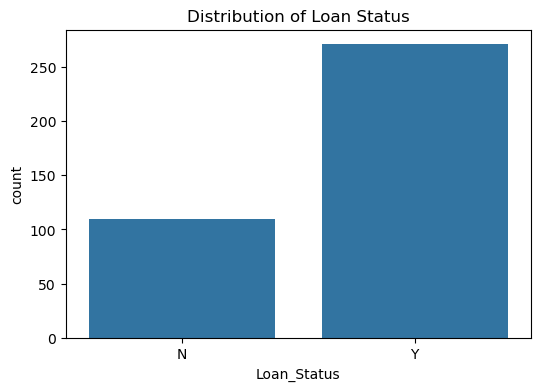

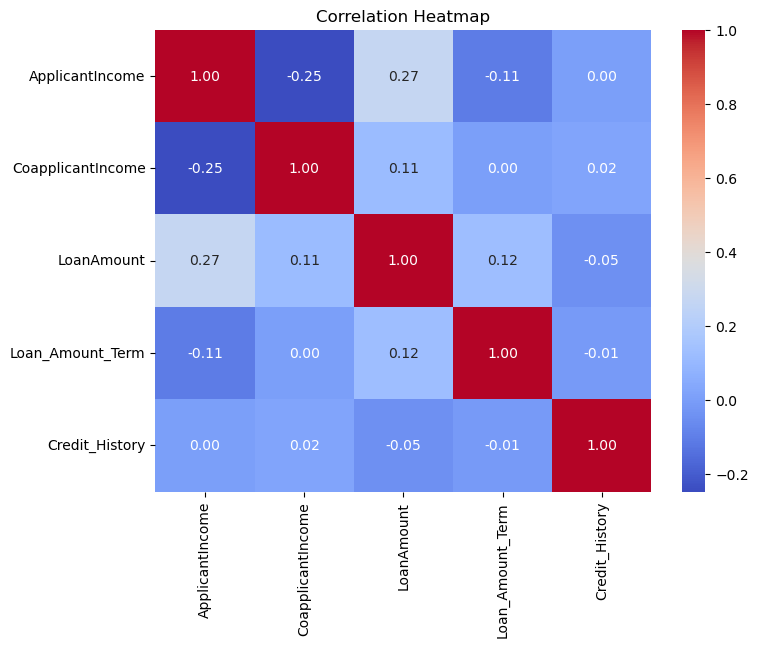

In [87]:
# Drop Loan_ID as it doesn't help the model predict anything
df = df.drop('Loan_ID', axis=1)

# Visualizing the Target Variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Distribution of Loan Status')
plt.show()

# Quick heatmap to see correlations between numerical features
numerical_cols = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# 1. Handle Missing Values
# Fill missing categorical values with the mode (most frequent)
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill missing numerical values with the median
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    df[col] = df[col].fillna(df[col].median())

# 2. Feature Engineering (Innovation points)
# Combining incomes often gives a better picture of repayment capacity
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# 3. Encode Categorical Variables
# Label Encoding for binary categories and Target
le = LabelEncoder()
cols_to_encode = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']
for col in cols_to_encode:
    df[col] = le.fit_transform(df[col])

# Replace 'Dependents' string '3+' with 3 and convert to integer (if applicable in full dataset)
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# One-Hot Encoding for nominal variables with >2 categories (Property_Area)
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

print("Pre-processing complete. Current shape:", df.shape)

Pre-processing complete. Current shape: (381, 14)


In [89]:
# Split features (X) and target (y)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Split into training and testing sets (80% train, 20% test)
# Note: With only 10 rows in this snippet, the test set is tiny, but this works for the full dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.55, random_state=42)

# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression (Baseline)
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
log_pred = log_reg.predict(X_test_scaled)

# Model 2: Random Forest Classifier (Advanced)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

In [90]:
print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, log_pred):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("Classification Report:\n", classification_report(y_test, log_pred, zero_division=0))

print("\n--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred, zero_division=0))

--- Logistic Regression Performance ---
Accuracy: 0.85
Confusion Matrix:
 [[ 28  30]
 [  1 151]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.48      0.64        58
           1       0.83      0.99      0.91       152

    accuracy                           0.85       210
   macro avg       0.90      0.74      0.78       210
weighted avg       0.87      0.85      0.83       210


--- Random Forest Performance ---
Accuracy: 0.88
Confusion Matrix:
 [[ 33  25]
 [  1 151]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.57      0.72        58
           1       0.86      0.99      0.92       152

    accuracy                           0.88       210
   macro avg       0.91      0.78      0.82       210
weighted avg       0.89      0.88      0.86       210

